In [1]:
!git clone https://github.com/nithinganesh1/Image_Classification.git

Cloning into 'Image_Classification'...
remote: Enumerating objects: 516, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 516 (delta 83), reused 93 (delta 38), pack-reused 343 (from 1)
Receiving objects: 100% (516/516), 110.42 MiB | 22.63 MiB/s, done.
Resolving deltas: 100% (93/93), done.


In [2]:
cd /content/Image_Classification

/content/Image_Classification


In [3]:
import tensorflow as tf
import os

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
import cv2
import imghdr

/tmp/ipykernel_1002/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [6]:
data_dir = 'data'

In [7]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [27]:
for image_class in os.listdir(data_dir):
    path = os.path.join(data_dir, image_class)
    if os.path.isdir(path):
        for image in os.listdir(path):
            image_path = os.path.join(path, image)
            try:
                img = cv2.imread(image_path)
                tip = imghdr.what(image_path)
                if tip not in image_exts:
                    print('Image not in ext list {}'.format(image_path))
                    os.remove(image_path)
            except Exception as e:
                print('Issue with image {}'.format(image_path))
                # os.remove(image_path)

In [28]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 297 files belonging to 2 classes.


In [29]:
data_iterator = data.as_numpy_iterator()


In [30]:
batch = data_iterator.next()

In [13]:
len(batch)

2

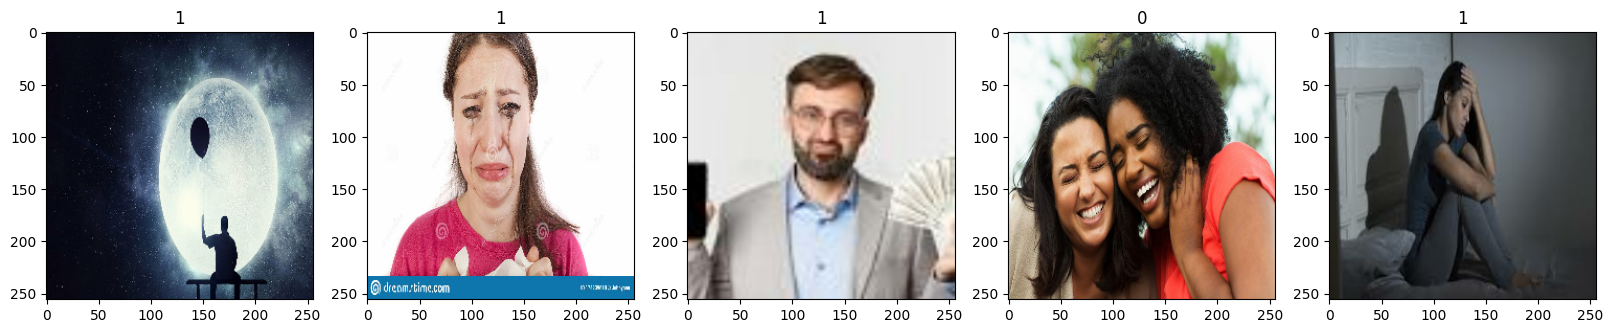

In [31]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])


In [32]:
data = data.map(lambda x,y: (x/255, y))

In [33]:
data.as_numpy_iterator().next()

(array([[[[0.95686275, 0.99607843, 0.9964461 ],
          [0.9632966 , 1.        , 0.9932598 ],
          [0.96862745, 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[0.9603445 , 0.9995602 , 0.99822307],
          [0.96441686, 1.        , 0.9943801 ],
          [0.96862745, 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[0.9607843 , 1.        , 0.99822307],
          [0.96721816, 1.        , 0.99718136],
          [0.96862745, 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         ...,
 
         [[1.        , 1.        , 1.        ],
          [1.     

In [34]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test

In [35]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [36]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [37]:
model = Sequential()

In [38]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [40]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
logdir = 'logs'

In [43]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [44]:
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step - accuracy: 0.5000 - loss: 0.7685 - val_accuracy: 0.6562 - val_loss: 0.6540
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 625ms/step - accuracy: 0.7098 - loss: 0.6566 - val_accuracy: 0.8906 - val_loss: 0.5838
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 813ms/step - accuracy: 0.7277 - loss: 0.5396 - val_accuracy: 0.7500 - val_loss: 0.4606
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 631ms/step - accuracy: 0.7857 - loss: 0.4520 - val_accuracy: 0.8750 - val_loss: 0.3720
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 649ms/step - accuracy: 0.8482 - loss: 0.3568 - val_accuracy: 0.9688 - val_loss: 0.2606
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 733ms/step - accuracy: 0.9330 - loss: 0.2409 - val_accuracy: 0.6719 - val_loss: 0.8071
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 619ms/step - accuracy: 0.8571 - loss: 0.3276 - val_accuracy: 0.9844 - val_loss: 0.1669
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 746ms/step - accuracy: 0.9554 - loss: 0.2411 - val_accuracy: 0.9219 - val_loss:

In [53]:
import cv2

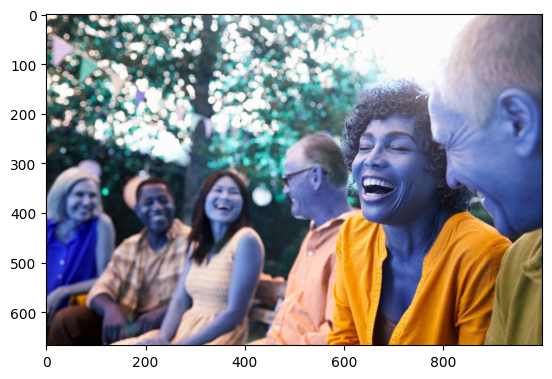

In [65]:
img = cv2.imread('/content/Image_Classification/data/happy/habits-of-happy-people.jpg')
plt.imshow(img)
plt.show()

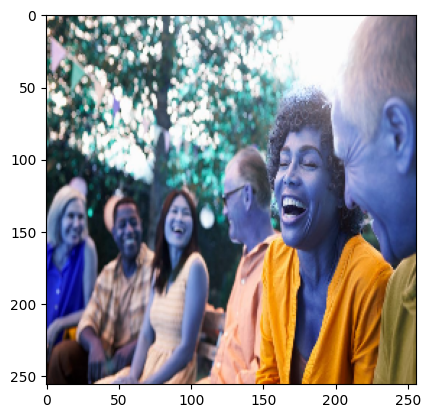

In [66]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [67]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [68]:
yhat

array([[2.6555039e-05]], dtype=float32)

In [69]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


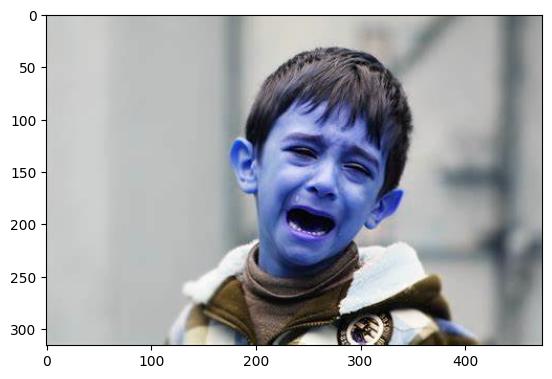

In [70]:
img = cv2.imread('sadimg.jpg')
plt.imshow(img)
plt.show()

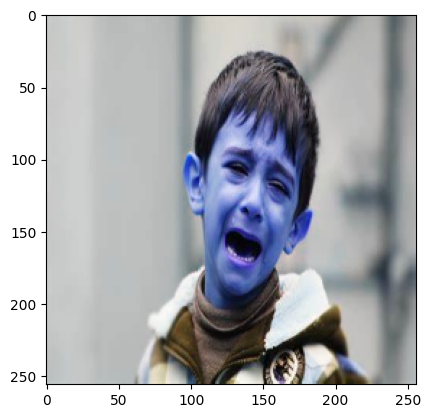

In [71]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [61]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [62]:
yhat

array([[0.98808074]], dtype=float32)

In [63]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


In [64]:
model.save(os.path.join('models','image_classifier_models.h5'))